# Systematic Generation or Enumeration of Solutions


Sometimes, when we solve a problem, we may want to or need to go through all possibile solutions or candidate solutions.  So, it's helpful to know different techniques to do this systematically.


In [ ]:
#PID:55
#
# Task: go through a list and print out all items of the list, and the largest item at the end
#
def find_max(L):
    for i in L:
        print(i)
    print(max(L))

find_max([1,5,10,3,6,25,2,7])

In [ ]:
#PID:56
#
# Task: print all pairs of numbers in L, at the end, print how many pairs with the second number
#       larger than the first number.  Orders of numbers matter.
#
def print_pairs(L):
    count = 0
    for i in range(len(L)):
        for j in range(len(L)):
            if i!=j:
                print((L[i], L[j]))
                if L[j] > L[i]:
                    count += 1
    print(count)
    
print_pairs([1,5,10,5])

In [ ]:
#PID:57
#
# Task: print all pairs of numbers in L, at the end, print how many pairs with the second number
#       larger than the first number.  Order of each pair numbers does not matter.
#
def print_pairs(L):
    count = 0
    for i in range(len(L)):
        for j in range(i+1, len(L)):
            print((L[i], L[j]))
            if L[j] > L[i]:
                count += 1
    print(count)

print_pairs([1,5,10,3,6,25,2,7])


In [ ]:
#PID:58
#
# Task: print out all 4-digit binary numbers
#
# Strategy: 
#  Create a nested 4-loop, each iterating through [0,1], which are the possible values of each digit.
#
def all_4_digit_numbers():
    for d1 in [0,1]:
        for d2 in [0,1]:
            for d3 in [0,1]:
                for d4 in [0,1]:
                    print(d1,d2,d3,d4)
all_4_digit_numbers()

0000, 0110, 1000, 1111, 1100, ...

There are 16 of them.


In [ ]:
def all_5_digit_numbers():
    for d1 in [0,1]:
        for d2 in [0,1]:
            for d3 in [0,1]:
                for d4 in [0,1]:
                    for d5 in [0,1]:
                        print(d1,d2,d3,d4,d5)
all_5_digit_numbers()

# Backtracking

In this lecture we will learn a general technique for **generating all solutions** to a problem by building them one piece at a time and undoing choices that don't lead anywhere useful. This technique is called **backtracking**.

**Learning objectives.** By the end of this lecture you should be able to:
- Describe a problem's **solution space** as a tree of partial and complete solutions.
- Write down the **contract** of a backtracking function (what it assumes, what it produces).
- Translate the contract into a recursive template.
- Extend the template to handle different **solution types** (sequences vs. subsets).
- Extend the template to handle **feasibility constraints**.


## The Conceptual Layer

The Solution Space is a tree, the search tree.

Backtracking asks us to think of the set of all possible solutions as a **tree**. For the 4-digit binary problem, every internal node of the tree is a **partial solution** (some positions filled, the rest left as `None`) and every leaf is a **complete solution**.

<img src="https://i.imgur.com/618KZBe.png" width="640"/>

**Terminology.**
- **Partial solution:** a list like `[0, 1, None, None]` — the first two positions are committed, the rest are undecided.
- **Complete solution:** a list with no `None` entries, like `[0, 1, 0, 1]`.

**Key idea.** Instead of building solutions all at once, we walk down this tree, making one choice at a time. When we hit a leaf, we have a complete solution.


Key Concepts:
- Think of generating all solutions as traversing a search tree. Leaves are all candidate solutions.
- Each internal node is an intermediate or *partial* solution.
- The key strategy to generate the solutions: consider all possible values to add to the "next level".

Technical Ideas:
- Use a list to represent a (partial or complete) solution: `solution`
- `len(solution)` is `n`
- What does complete solution look like (e.g. 0101)?  `solution = [0,1,0,1]`
- `solution[0], solution[1], ..., solution[i-1]` is a path from the root to an internal node.
- `[solution[0], solution[1], ..., solution[i-1]]` is an internal node or a partial solution 

### Key idea #1
- How to extend an internal node to the next one, or
- How to go from one node to the next-level nodes

Answer: consider all possible values and assign to `solution[i]`.

### Key idea #2

- After you assign a value to `solution[i]`, what do we do next to generate all the remaining solutions?

Answer: follow the same procedure/strategy.

In [ ]:

#
# backtrack(solution, i, possibilities) generates/enumerates/goes through solutions in 
# a search space (search tree) starting from the partial solution solution[0],...,solution[i-1]. 
# And possibilities are the possible values that can go into solution[i]
#
def backtrack(solution, i, possibilities):
    if i==len(solution):
        # if solution is complete, we are done
        print(solution)
    else:
        for possibility in possibilities:
            solution[i] = possibility
            backtrack(solution, i+1, possibilities)

In [ ]:
backtrack([None]*3, 0, [0,1])

### Understanding the "backtrack" template

What does this do?

```python
backtrack(solution, i, possibilities)
```




`backtrack(solution, i, possibilities)` generates/enumerates/goes through solutions in a search space (search tree) starting from the partial solution `solution[0],...,solution[i-1]`.  And `possibilities` are the possible values that can go into `solution[i]`



In [ ]:
#PID:59

# Task: generate all 4-digit binary numbers that start with 1

#
# backtrack(solution, i, possibilities) generates/enumerates/goes through solutions in 
# a search space (search tree) starting from the partial solution solution[0],...,solution[i-1]. 
# And possibilities are the possible values that can go into solution[i]
#
def backtrack(solution, i, possibilities):
    if i==len(solution):
        # if solution is complete, we are done
        print(solution)
    else:
        for possibility in possibilities:
            solution[i] = possibility
            backtrack(solution, i+1, possibilities)

backtrack([1,None,None,None], 1, [0,1])


1000, 1001, 1101, etc.

In [ ]:
#PID:60

# Task: generate all 4-digit binary numbers that have the same 0's and 1'

#
# backtrack(solution, i, possibilities) generates/enumerates/goes through solutions in 
# a search space (search tree) starting from the partial solution solution[0],...,solution[i-1]. 
# And possibilities are the possible values that can go into solution[i]
#
def backtrack(solution, i, possibilities):
    if i==len(solution): # solution is complete
        if solution.count(0) == solution.count(1): # solution is valid
            print(solution)
    else:
        for possibility in possibilities:
            solution[i] = possibility
            backtrack(solution, i+1, possibilities)

# Examples: 1001, 1010, ...
backtrack([None]*4, 0, [0,1])

# A new backtrack template

At the end (when a solution has been completed constructed), we can check to see if the solution is valid or not. In some applications, complete solutions are not necessarily valid.

In [ ]:
def backtrack(solution, i, possibilities, is_valid):
    if i==len(solution):
        if is_valid(solution):
            print(solution)
    else:
        for possibility in possibilities:
            solution[i] = possibility
            backtrack(solution, i+1, possibilities, is_valid)

In [ ]:
def same_01s(solution):
    return solution.count(0) == solution.count(1)
    
backtrack([None]*4, 0, [0,1], same_01s)

#PID:61


Suppose the task is this: generate 6-digit binary numbers that have no consecutive 1's.

Examples: 101010, 010101, 001010, ...

Question: how and where should we modify this algorithm?

Answer: before we assign `solution[i]` to a `possibility`, check if that assignment is allowed.

```python
def backtrack(solution, i, possibilities, is_valid):
    if i==len(solution):
        if is_valid(solution):
            print(solution)
    else:
        for possibility in possibilities:
            # should we allow this assignment?
            if not (i>0 and possibility==1 and solution[i-1]==1):
                solution[i] = possibility
                backtrack(solution, i+1, possibilities, is_valid)
```

In [ ]:
def backtrack(solution, i, possibilities, is_valid):
    if i==len(solution):
        if is_valid(solution):
            print(solution)
    else:
        for possibility in possibilities:
            if not (i>0 and possibility==1 and solution[i-1]==1):
                solution[i] = possibility
                backtrack(solution, i+1, possibilities, is_valid)

In [ ]:
backtrack([None]*6, 0, [0,1], lambda solution: True)

### Tree prunning

> We don't want to extend the search into branches that will lead to invalid solutions.

**possibilities** is no longer a list of values.  We want this to be more dynamic.  Now, **possibilities* is a function that returns all possible values for `solution[i]`.

The current partial solution is: `solution[0], ... solution[i-1]`.

This is most general template we have for backtracking:

In [ ]:
#
# OUR MOST GENERAL BACKTRACK TEMPLATE
#
def backtrack(solution, 
              possibilities, 
              i = 0, 
              is_valid=lambda solution: True,
              display_solution=lambda s: s):
    if i==len(solution):
        if is_valid(solution):
            print(display_solution(solution))
    else:
        for possibility in possibilities(solution, i):
            solution[i] = possibility
            backtrack(solution, possibilities, i+1, is_valid, display_solution)

            

>Task: generate all 4-digit binary numbers, which have no consecutive 1's.

In [ ]:
#
# possibilities function
#
def no_consecutive_1s(solution, i):
    if i==0 or solution[i-1]=='0':
        return ['0','1']
    else:
        return ['0']
            
backtrack([None]*4, no_consecutive_1s)

In [ ]:
# display solutions as strings
backtrack([None]*4, 
          no_consecutive_1s,
          display_solution = lambda s: ''.join(s))

### OUR MOST GENERAL BACKTRACK TEMPLATE

```python
def backtrack(solution, 
              possibilities, 
              i = 0, 
              is_valid=lambda solution: True,
              display_solution=lambda s: s):
    if i==len(solution):
        if is_valid(solution):
            print(display_solution(solution))
    else:
        for possibility in possibilities(solution, i):
            solution[i] = possibility
            backtrack(solution, possibilities, i+1, is_valid, display_solution)
```

---

`solution` is a list that represents the current solution while we are systematically going through all solutions, one at a time.

There are two main types of solutions: unordered lists (sets) and ordered lists.

---
### "Sets"

So far, each `solution[i]` has been an **actual item** — a digit, a fruit name, etc. This works well when we are generating **sequences** (ordered choices, possibly with repetition).

But consider this task:

> *Given the fruits `['apple', 'orange', 'banana']`, list every **subset** of them.*

Examples: {}, {apple}, {orange}, {banana}, {apple,orange}, {apple,banana}, {orange,banana}, {apple,orange,banana}



A subset isn't naturally a sequence. How do we represent it?

**Idea: an indicator list.** Let `solution[i] = True` mean "`fruits[i]` is in the subset", and `solution[i] = False` mean "it isn't." Then every list of `True`/`False` of length 3 corresponds to exactly one subset, and vice versa.

So a "solution" can be:
1. **Items directly**, e.g. `solution[i] = 'apple'`.
2. **Indicators**, e.g. `solution[i] = True` meaning "include `fruits[i]`."


Given `[apple, orange, banana]`, how do we represent:
- {apple} -> [True, False, False]
- {apple, banana} -> [True, False, True]

In [ ]:
# Print every subset of the given fruit list, using an indicator-based solution.
fruits = ['apple', 'orange', 'banana']

def show_fruits(sol):
    pass   # to be filled in during class

#
# given the partial solution (solution[0], ..., solution[i-1]), what
# are the possible values that can be assigned solution[i]
def possible_fruits(sol, i):
    return [True,False]

# all possible sets of T/F for 3 items
backtrack([None]*3, possible_fruits)


In [ ]:
def display_fruits(solution):
    s = ['appple','orange','banana']
    return { s[i] for i in range(len(solution)) if solution[i]==True }
    
# all possible sets of fruits
backtrack([None]*3, possible_fruits, display_solution = display_fruits)


In [53]:
#PID:62

# Task: generate all sets of {apple,orange,banana,grape} that don't have both apple and grape
#
def backtrack(solution, 
              possibilities, 
              i = 0, 
              is_valid=lambda solution: True,
              display_solution=lambda s: s):
    if i==len(solution):
        if is_valid(solution):
            print(display_solution(solution))
    else:
        for possibility in possibilities(solution, i):
            solution[i] = possibility
            backtrack(solution, possibilities, i+1, is_valid, display_solution)

def display_fruits(solution):
    s = ['appple','orange','banana','grape']
    return { s[i] for i in range(len(solution)) if solution[i]==True }


# 1. when we have a complete solution, make sure it doesn't have both apple and grape

def possible_fruits(sol, i):
    return [True,False]
backtrack([None]*4, possible_fruits, display_solution = display_fruits,
         is_valid = lambda s: not (s[0]==True and s[3]==True))

print()


# 2. When grape is considered, check to see if apple is selected or not
def possible_fruits(sol, i):
    if i==3 and sol[0]==True:
        return [False]
    return [True,False]

backtrack([None]*4, possible_fruits, display_solution = display_fruits)


{'orange', 'appple', 'banana'}
{'orange', 'appple'}
{'appple', 'banana'}
{'appple'}
{'orange', 'banana', 'grape'}
{'orange', 'banana'}
{'orange', 'grape'}
{'orange'}
{'grape', 'banana'}
{'banana'}
{'grape'}
set()

{'orange', 'appple', 'banana'}
{'orange', 'appple'}
{'appple', 'banana'}
{'appple'}
{'orange', 'banana', 'grape'}
{'orange', 'banana'}
{'orange', 'grape'}
{'orange'}
{'grape', 'banana'}
{'banana'}
{'grape'}
set()


```python
def backtrack(solution, 
              possibilities, 
              i = 0, 
              is_valid=lambda solution: True,
              display_solution=lambda s: s):
    if i==len(solution):
        if is_valid(solution):
            print(display_solution(solution))
    else:
        for possibility in possibilities(solution, i):
            solution[i] = possibility
            backtrack(solution, possibilities, i+1, is_valid, display_solution)
```

To solve a problem correctly using backtrack, we have know (1) what valid solutions are, and (2) the possible values that can be assigned to `solution[i]`.

Implicitly, we have to know what `solution` represents.

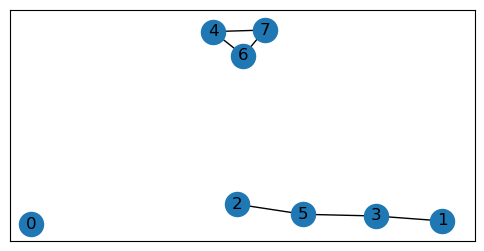

In [89]:
import networkx as nx
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))

G = nx.Graph()
G.add_edges_from([(1, 2), (1, 3), (2, 3), (3, 4), (4, 5)])
# nx.draw_networkx(G)

# An independent set: {0, 6, 2} don't know each other
my_network = nx.gnp_random_graph(8, 0.25, seed=423)
nx.draw_networkx(my_network)

### Task: find all independent sets of size 3.

An independent set is a set of nodes of a graph without any connections among these nodes.

In [138]:
my_network.edges

EdgeView([(1, 3), (2, 5), (3, 5), (4, 6), (4, 7), (6, 7)])

In [150]:
# check if final solution is a 3-node independent set
my_network = nx.gnp_random_graph(8, 0.25, seed=423)
solution = [None]*len(my_network)

def possibilities(sol, i):
    return [True,False]

def display_set(sol):
    return { i for i in range(len(sol)) if sol[i]==True } 

def three_node_independent_set(sol):
    nodes = [ i for i in range(len(sol)) if sol[i]==True ]
    if len(nodes)!=3:
        return False
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            if (nodes[i],nodes[j]) in my_network.edges:
                return False
    return True
    
backtrack(solution, 
          possibilities, 
          is_valid = three_node_independent_set,
          display_solution = display_set)

{0, 1, 2}
{0, 1, 4}
{0, 1, 5}
{0, 1, 6}
{0, 1, 7}
{0, 2, 3}
{0, 2, 4}
{0, 2, 6}
{0, 2, 7}
{0, 3, 4}
{0, 3, 6}
{0, 3, 7}
{0, 4, 5}
{0, 5, 6}
{0, 5, 7}
{1, 2, 4}
{1, 2, 6}
{1, 2, 7}
{1, 4, 5}
{1, 5, 6}
{1, 5, 7}
{2, 3, 4}
{2, 3, 6}
{2, 3, 7}


In [101]:
my_network.edges

EdgeView([(1, 3), (2, 5), (3, 5), (4, 6), (4, 7), (6, 7)])

In [113]:
(1,3) in my_network.edges, (3,1) in my_network.edges

(True, True)

### Ordered Lists

The order of items is important for many types of solutions.


Suppose you want to take 4 courses from a list of 5 courses `[1900, 2150, 3410, 4030, 4081]`.

How many ways can we do this?
- No course taken twice.
- The course numbers have to sorted.
  

In [158]:
courses = [1900, 2150, 3410, 4030, 4081, 4601]
solution = [None]*4

# solution[i] is a course, potentially with values {1900, 2150, 3410, 4030, 4081}

def possibilities(sol, i):
    if i==0:
        return [1900, 2150,3410]
    return [ courses[j] for j in range(len(courses)) if courses[j] > sol[i-1] ]
    
backtrack(solution, possibilities)


[1900, 2150, 3410, 4030]
[1900, 2150, 3410, 4081]
[1900, 2150, 3410, 4601]
[1900, 2150, 4030, 4081]
[1900, 2150, 4030, 4601]
[1900, 2150, 4081, 4601]
[1900, 3410, 4030, 4081]
[1900, 3410, 4030, 4601]
[1900, 3410, 4081, 4601]
[1900, 4030, 4081, 4601]
[2150, 3410, 4030, 4081]
[2150, 3410, 4030, 4601]
[2150, 3410, 4081, 4601]
[2150, 4030, 4081, 4601]
[3410, 4030, 4081, 4601]


#### N-Queens

